In [10]:
import pandas as pd

In [11]:
df=pd.read_csv("heart.csv")
df
print(df.to_string())

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
0     40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
1     49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
2     37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
3     48   F           ASY        138          214          0     Normal    108              Y      1.5     Flat             1
4     54   M           NAP        150          195          0     Normal    122              N      0.0       Up             0
5     39   M           NAP        120          339          0     Normal    170              N      0.0       Up             0
6     45   F           ATA        130          237          0     Normal    170              N      0.0       U

In [12]:
print(df.head())
print(df.isnull().sum())
print("duplicated values: ")
print(df.duplicated().sum())


   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slop

Balance of data HeartDisease
1    508
0    410
Name: count, dtype: int64


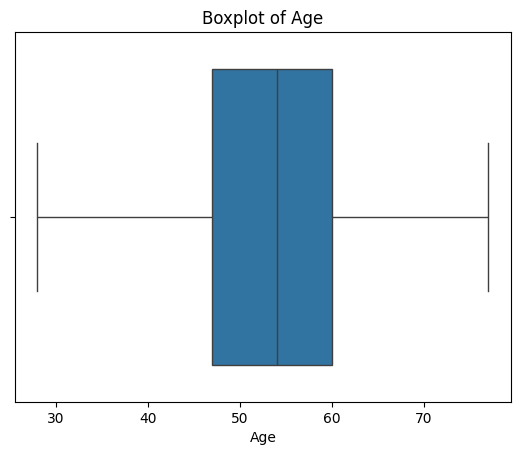

In [13]:
print('Balance of data', df['HeartDisease'].value_counts())
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Age'] >= Q1 - 1.5*IQR) & (df['Age'] <= Q3 + 1.5*IQR)]

import seaborn as sns
import matplotlib.pyplot as plt

# now i visualize 'Age' for outliers
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

In [14]:
# Convert all bools to int (0/1)
df = pd.get_dummies(df).astype(int)
#take df and check for categorical variables and trasnform these values into 0 and 1 
print(df)

     Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0     40        140          289          0    172        0             0   
1     49        160          180          0    156        1             1   
2     37        130          283          0     98        0             0   
3     48        138          214          0    108        1             1   
4     54        150          195          0    122        0             0   
..   ...        ...          ...        ...    ...      ...           ...   
913   45        110          264          0    132        1             1   
914   68        144          193          1    141        3             1   
915   57        130          131          0    115        1             1   
916   57        130          236          0    174        0             1   
917   38        138          175          0    173        0             0   

     Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  \
0        0 

In [15]:
from sklearn.preprocessing import StandardScaler
numerical=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler=StandardScaler()

In [16]:
df[numerical]=scaler.fit_transform(df[numerical]) 
df

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,0,1.382928,-0.727592,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.491752,-0.171961,0,0.754157,0.282891,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.129513,0.770188,0,-1.525138,-0.727592,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.302825,0.139040,0,-1.132156,0.282891,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.951331,-0.034755,0,-0.581981,-0.727592,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.210356,0.596393,0,-0.188999,0.282891,1,0,1,0,...,0,1,0,1,0,1,0,0,1,0
914,1.536902,0.627078,-0.053049,1,0.164684,2.303858,1,0,1,1,...,0,0,0,1,0,1,0,0,1,0
915,0.370100,-0.129513,-0.620168,0,-0.857069,0.282891,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
916,0.370100,-0.129513,0.340275,0,1.461525,-0.727592,1,1,0,0,...,0,0,1,0,0,1,0,0,1,0


In [17]:
y = df['HeartDisease']

In [18]:
X = df.drop('HeartDisease', axis=1) #1 to remove whole column, 0 to remove whole row
#or use X=df.loc[:, df.columns != 'HeartDisease'] 

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('HeartDisease',axis=1),df['HeartDisease'],test_size=0.2,random_state=42)
#42 is the answer to the ultimate question of life, the universe, and everything. It is a common practice to use 42 as a random state in machine learning experiments to ensure reproducibility. By setting the random state to a specific value, you can ensure that the same random numbers are generated each time you run the code, which can be helpful for debugging and comparing results across different runs.


In [21]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [22]:
model = LogisticRegression()
model.fit(x_train,y_train)    
y_pred=model.predict(x_test)


In [23]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_pred, y_test)
accuracy

0.8586956521739131

Hyperparameter tuning


In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
grid_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', 'elastic'],
    'solver': ['liblinear', 'saga', 'lbfgs']
}

In [26]:
grid = GridSearchCV(LogisticRegression(max_iter = 500), grid_params, cv = 5, scoring = 'accuracy') #divides the train data into 5 chunks, trains on 4 and tests 


In [27]:
grid.fit(x_train, y_train)
print("Best parameters: ", grid.best_params_)
print("Best cross-validation score: ", grid.best_score_)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters:  {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best cross-validation score:  0.863768521107073


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
100 fits failed out of a total of 225.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Admin\AppD

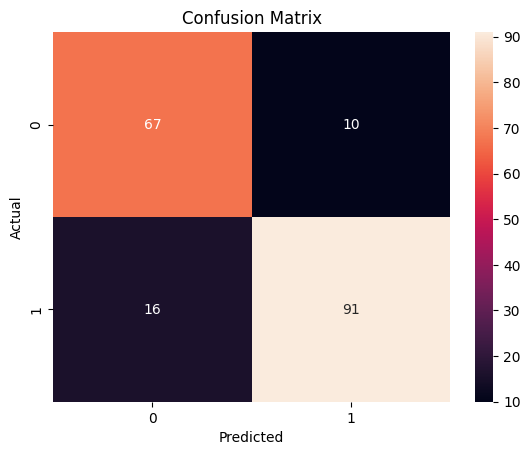

In [28]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Precision: 0.900990099009901
Recall: 0.8504672897196262

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

